In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('zomato-dataset.csv')
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [3]:
print(f"Rows: {df.shape[0]}, Colums: {df.shape[1]}")

Rows: 148, Colums: 7


In [4]:
df.shape

(148, 7)

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,148,145,San Churro Cafe,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_order,148,2,No,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_table,148,2,No,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate,148,20,3.8/5,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
votes,148.0,NaN,NaN,NaN,264.810811,653.676951,0.0,6.75,43.5,221.75,4884.0
approx_cost(for two people),148.0,NaN,NaN,NaN,418.243243,223.085098,100.0,200.0,400.0,600.0,950.0
listed_in(type),148,4,Dining,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [7]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

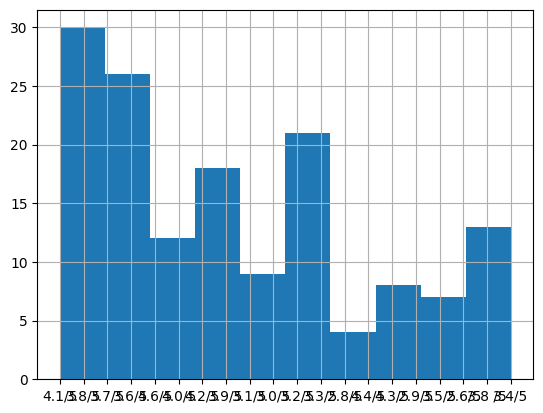

In [9]:
df['rate'].hist()
plt.show()

In [10]:
df['rate'] = df['rate'].str.replace('/5', ' ')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [13]:
df.rename(columns={'rate': 'rating_out_of_5'}, inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rating_out_of_5              148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


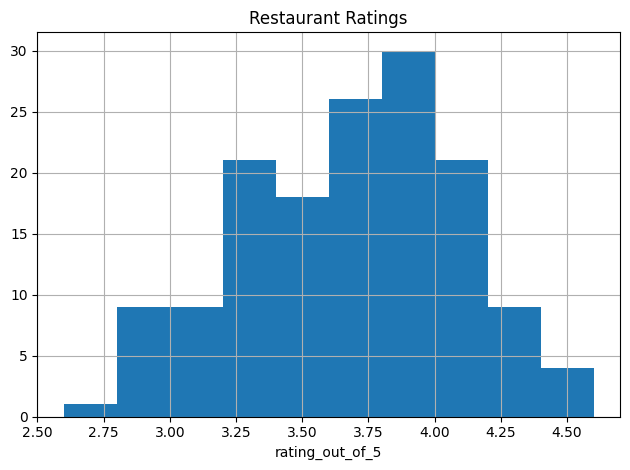

In [16]:
df['rating_out_of_5'].hist()
plt.title('Restaurant Ratings')
plt.xlabel('rating_out_of_5')
plt.tight_layout()
plt.show()

In [17]:
df.to_csv('Cleaned-zomato-dataset.csv', index=False)

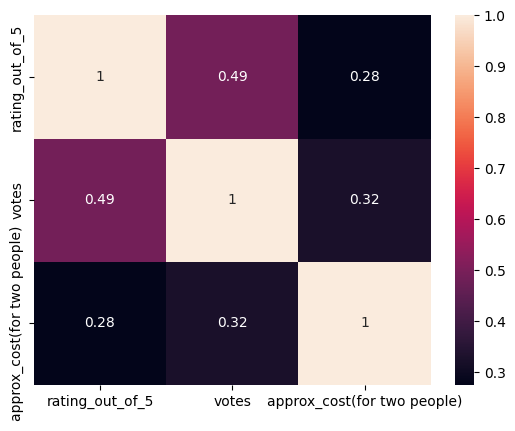

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['rating_out_of_5', 'votes', 'approx_cost(for two people)']].corr()

sns.heatmap(corr, annot=True)
plt.show()

In [20]:
df[df['votes'] > 50].groupby('rating_out_of_5')['votes'].mean()

rating_out_of_5
2.6     283.000000
2.8     298.500000
2.9      84.000000
3.0      80.000000
3.1     245.000000
3.2      71.000000
3.3      62.000000
3.5      52.000000
3.6     164.600000
3.7     203.333333
3.8     237.714286
3.9     297.285714
4.0     564.555556
4.1     728.875000
4.2     453.000000
4.3     345.000000
4.4    4642.500000
4.6    2556.000000
Name: votes, dtype: float64

In [21]:
df['approx_cost(for two people)'].describe()

count    148.000000
mean     418.243243
std      223.085098
min      100.000000
25%      200.000000
50%      400.000000
75%      600.000000
max      950.000000
Name: approx_cost(for two people), dtype: float64

In [22]:
df[df['votes'] > 50].groupby('rating_out_of_5')['votes'].mean()

rating_out_of_5
2.6     283.000000
2.8     298.500000
2.9      84.000000
3.0      80.000000
3.1     245.000000
3.2      71.000000
3.3      62.000000
3.5      52.000000
3.6     164.600000
3.7     203.333333
3.8     237.714286
3.9     297.285714
4.0     564.555556
4.1     728.875000
4.2     453.000000
4.3     345.000000
4.4    4642.500000
4.6    2556.000000
Name: votes, dtype: float64